# NUM model on an A100: one model year at 2.8°

This notebook shows the global NUM run computed on a **RunPod NVIDIA A100 80 GB** by the Julia/CUDA
port (`julia/NUMGPU`), next to the same year computed by the **unmodified upstream Matlab + Fortran
model** (NUMmodel v1.0, `scripts/run_reference_global.m`, 5 parallel workers on this laptop).

* Setup: `setupNUMmodel` (10 generalists, 10 diatoms, 5 copepod groups × 6 stages, 1 POM), MITgcm 2.8°
  transport matrices (converted TMM `ironmops` example), 0.1 d Euler biology, 0.5 d transport, 365 days.
* Both runs start from the same initial condition and forcing. This is **year 1 from the initial
  condition**, not a spun-up state, so it will not look exactly like published multi-year NUM figures. The GPU run is the first A100 run
  (array biology, 89 s wall clock including compilation); the fused kernel now does a model year in ~6.5 s.
* Pointwise agreement is not expected everywhere: some surface boxes (mostly the tropical eastern
  Pacific) are sensitive to round-off, so two runs differing by 1e-15 diverge there within days.
  Global and regional patterns, inventories and spectra should match.

Figures follow the standard NUM diagnostics (Serra-Pompei et al. 2022, *Global Biogeochem. Cycles*;
Andersen & Visser NUM papers): depth-integrated biomass maps by group, size spectra, pico/nano/micro split.

In [1]:
import json
from pathlib import Path
import h5py
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
warnings.filterwarnings("ignore", message="Mean of empty slice")

REF = (Path("../reference") if Path("../reference").exists() else Path("reference")).resolve()
FILES = {"A100 (Julia/CUDA)": REF / "julia_gpu_1yr_sim.mat",
         "Matlab + Fortran":  REF / "global_2p8_1yr_setupNUMmodel.mat"}

def load_sim(path):
    # Matlab/MAT.jl v7.3 files read by h5py come out with reversed dimensions: transpose back to
    # Matlab order (t, x, y, z[, class]).
    with h5py.File(path, "r") as h:
        s = h["sim"]
        d = {k: np.array(s[k]).T for k in ("N", "Si", "DOC", "T", "L", "B")}
        for k in ("x", "y", "z", "dznom", "t"):
            d[k] = np.array(s[k]).ravel()
    return d

sims = {name: load_sim(p) for name, p in FILES.items()}
classes = json.loads((REF / "num_classes.json").read_text())
m = np.array([c["m"] for c in classes]); mLower = np.array([c["mLower"] for c in classes])
mDelta = np.array([c["mDelta"] for c in classes]); ctype = np.array([c["type"] for c in classes])
cgroup = np.array([c["group"] for c in classes])
g = sims["A100 (Julia/CUDA)"]
x, y, z, dz, t = g["x"], g["y"], g["z"], g["dznom"], g["t"]
ocean = ~np.isnan(g["N"][0, :, :, 0])          # surface wet points
print({k: v["B"].shape for k, v in sims.items()}, "classes:", len(m))
print("groups:", {t_: int((ctype == t_).sum()) for t_ in dict.fromkeys(ctype)})

{'A100 (Julia/CUDA)': (12, 128, 64, 15, 51), 'Matlab + Fortran': (12, 128, 64, 15, 51)} classes: 51
groups: {np.str_('Generalists'): 10, np.str_('Diatoms'): 10, np.str_('Passive copepods'): 12, np.str_('Active copepods'): 18, np.str_('POM'): 1}


In [2]:
print((REF / "run_gpu_1yr.txt").read_text().strip().splitlines()[-1])
print("Matlab reference: 3043 s on 5 workers (laptop).  Fused-kernel A100 years 2-3: 6.4 s / 6.9 s")

WALL CLOCK 365.0 days: 89.0 s (1.5 min), GPU
Matlab reference: 3043 s on 5 workers (laptop).  Fused-kernel A100 years 2-3: 6.4 s / 6.9 s


## 1. Global nitrogen inventory

Total nitrogen (dissolved N + biomass/ρ_CN) integrated over the ocean volume, as `calcGlobalN.m`.
The model loses a little N through POM sinking out of the bottom cells and gains some through the
bottom boundary condition; both runs should trace the same curve.

rhoCN = 5.68


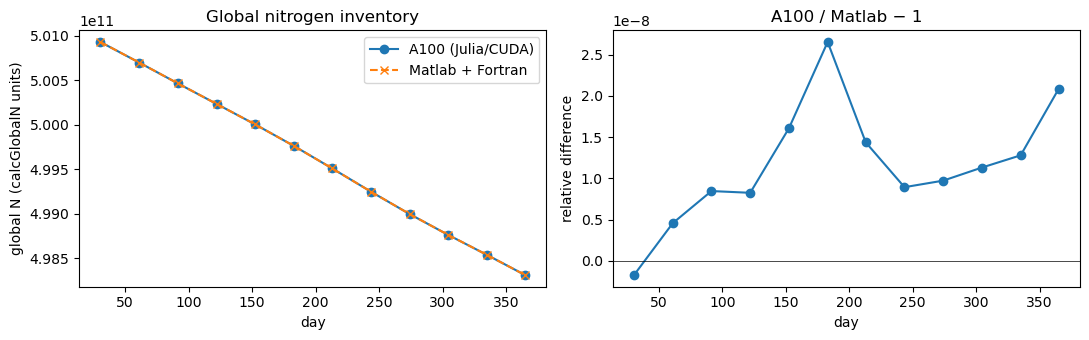

In [3]:
from scipy.io import loadmat
import re
ROOT = REF.parent
dv = loadmat(ROOT / "NUMmodel/TMs/MITgcm_2.8deg/grid.mat")["dv"]            # box volumes (m^3), nx×ny×nz
rhoCN = float(re.search(r"rhoCN\s*=\s*([0-9.eEdD+-]+)", (ROOT / "NUMmodel/input/input.h").read_text())
              .group(1).replace("d", "e").replace("D", "e"))
print("rhoCN =", rhoCN)
def Ntot(s):
    tot = np.nan_to_num(s["N"]) + np.nan_to_num(s["B"]).sum(axis=4) / rhoCN   # ugN/l = mgN/m3
    return (tot * dv[None]).sum(axis=(1, 2, 3)) / 1000 * 1e-6                     # as calcGlobalN
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for name, s in sims.items():
    ax[0].plot(t, Ntot(s), "o-" if "A100" in name else "x--", label=name)
ax[0].set(xlabel="day", ylabel="global N (calcGlobalN units)", title="Global nitrogen inventory")
ax[0].legend()
r = Ntot(sims["A100 (Julia/CUDA)"]) / Ntot(sims["Matlab + Fortran"]) - 1
ax[1].plot(t, r, "o-"); ax[1].axhline(0, color="k", lw=0.5)
ax[1].set(xlabel="day", ylabel="relative difference", title="A100 / Matlab − 1")
plt.tight_layout()

## 2. Depth-integrated biomass by group (annual mean)

Like `plotGlobalGroups.m`: biomass summed over the size classes of each group and integrated over
depth (g C m⁻²), log₁₀ scale. Left: A100 run; right: Matlab run.

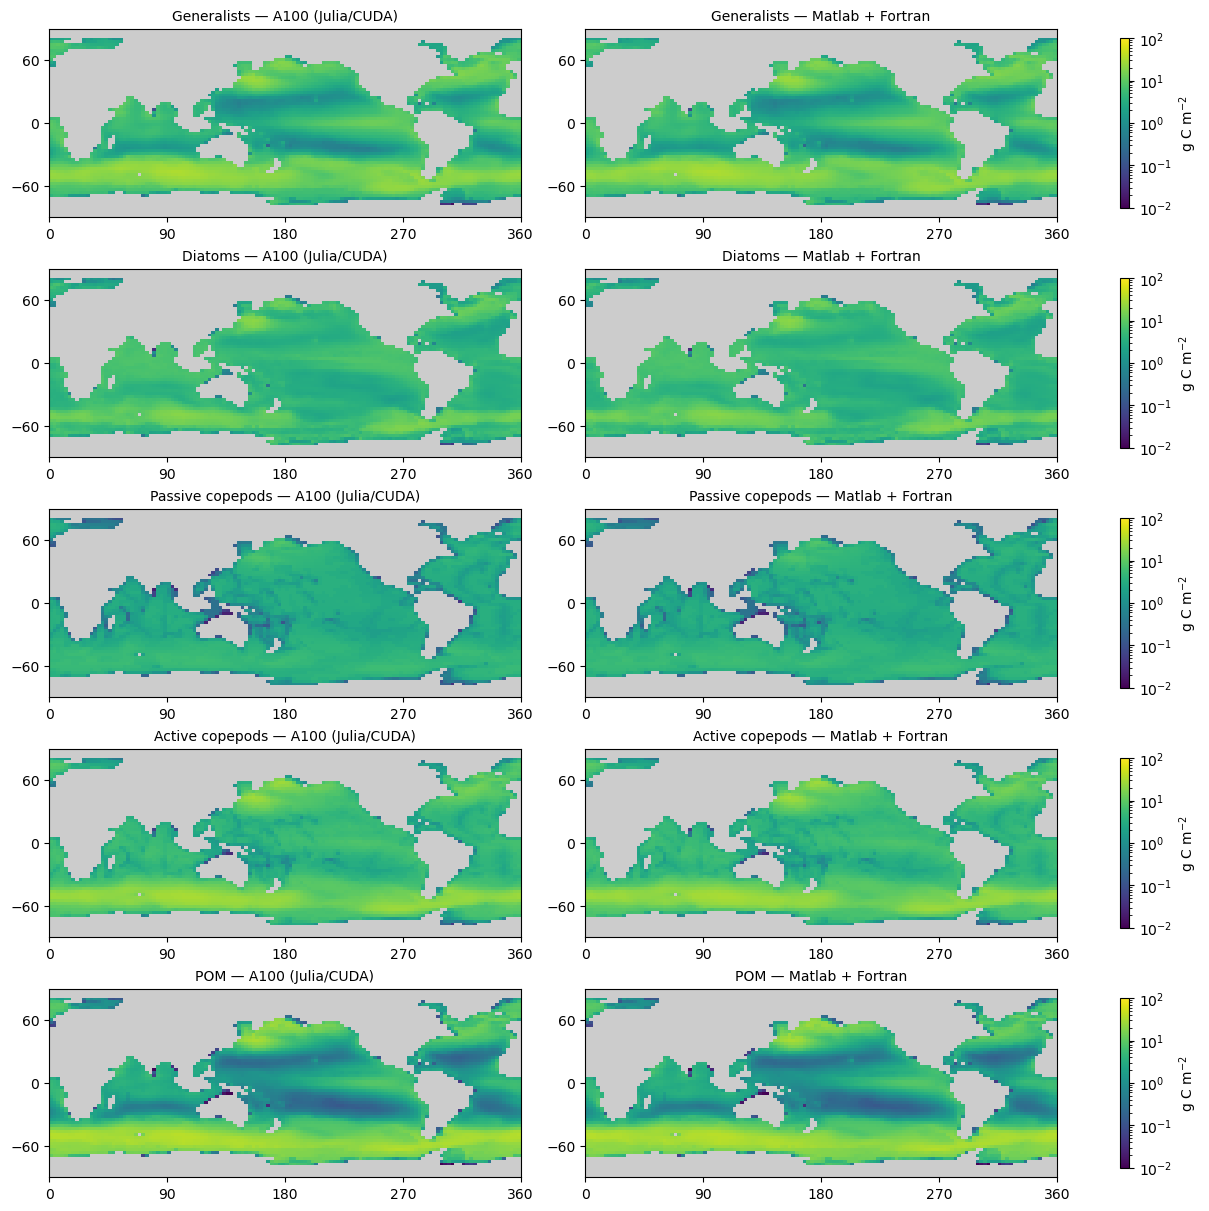

In [4]:
def integrated(s, sel):
    B = np.nan_to_num(s["B"][..., sel]).sum(axis=4)              # t,x,y,z
    I = (B * dz[None, None, None, :]).sum(axis=3) / 1000          # g C / m^2
    return np.where(ocean[None], I, np.nan)

def gmap(ax, field, title, vmin=1e-1, vmax=1e2, cmap="viridis"):
    ax.set_facecolor("0.8")
    pc = ax.pcolormesh(x, y, field.T, norm=LogNorm(vmin, vmax), cmap=cmap, shading="auto")
    ax.set_title(title, fontsize=10); ax.set_xticks([0, 90, 180, 270, 360]); ax.set_yticks([-60, 0, 60])
    return pc

groups = list(dict.fromkeys(ctype))
fig, axs = plt.subplots(len(groups), 2, figsize=(12, 2.4 * len(groups)), constrained_layout=True)
annual = {}
for i, grp in enumerate(groups):
    sel = ctype == grp
    for j, (name, s) in enumerate(sims.items()):
        annual[(grp, name)] = integrated(s, sel).mean(axis=0)
        pc = gmap(axs[i, j], annual[(grp, name)], f"{grp} — {name}", 1e-2, 1e2)
    fig.colorbar(pc, ax=axs[i, :], label="g C m$^{-2}$", shrink=0.9)

## 3. Do the two runs agree box by box?

Annual-mean depth-integrated biomass of each group in every water column, A100 vs Matlab.
Points on the 1:1 line mean the same answer; the few off-line points are the round-off-sensitive
surface boxes.

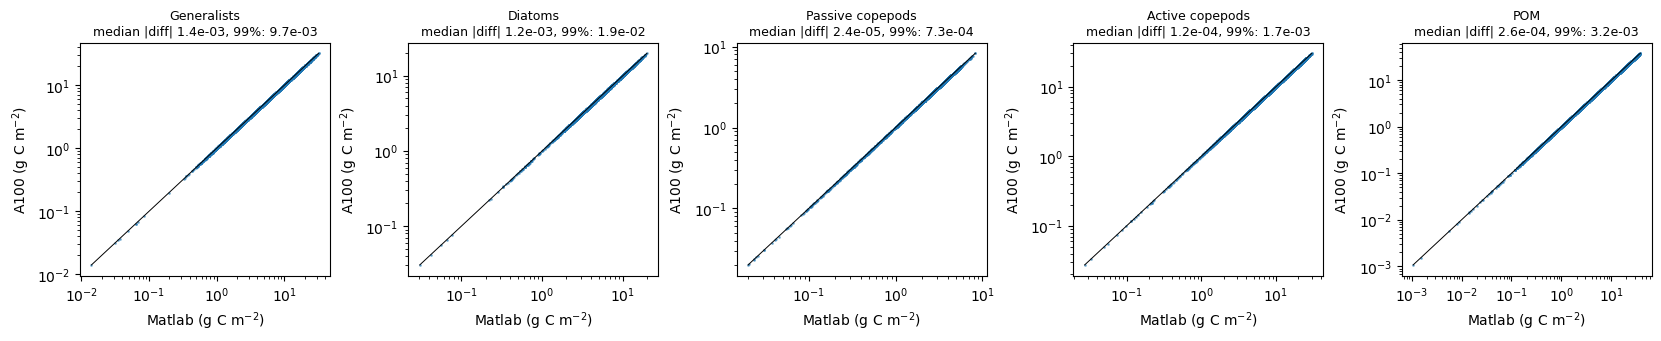

In [5]:
fig, axs = plt.subplots(1, len(groups), figsize=(3.3 * len(groups), 3.3), constrained_layout=True)
for ax, grp in zip(axs, groups):
    a = annual[(grp, "A100 (Julia/CUDA)")][ocean]; b = annual[(grp, "Matlab + Fortran")][ocean]
    ok = (a > 1e-6) & (b > 1e-6)
    ax.loglog(b[ok], a[ok], ".", ms=2, alpha=0.5)
    lo, hi = min(b[ok].min(), a[ok].min()), max(b[ok].max(), a[ok].max())
    ax.plot([lo, hi], [lo, hi], "k-", lw=0.7)
    rel = np.abs(a[ok] / b[ok] - 1)
    ax.set_title(f"{grp}\nmedian |diff| {np.median(rel):.1e}, 99%: {np.quantile(rel, .99):.1e}", fontsize=9)
    ax.set_xlabel("Matlab (g C m$^{-2}$)"); ax.set_ylabel("A100 (g C m$^{-2}$)")

## 4. Surface nutrients (annual mean)

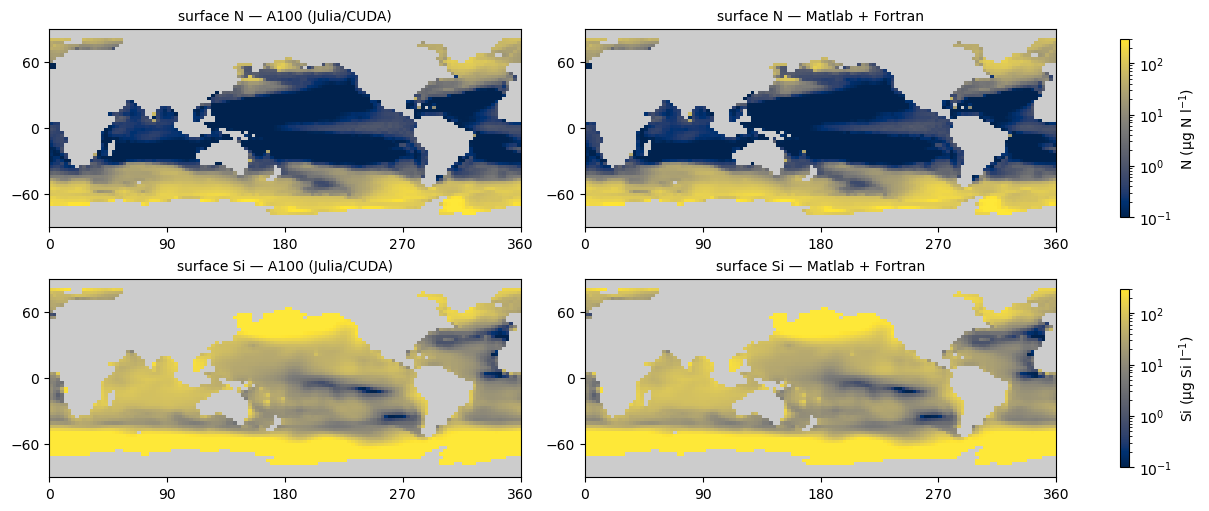

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True)
for i, (var, lab, vmin, vmax) in enumerate([("N", "N (µg N l$^{-1}$)", 1e-1, 3e2), ("Si", "Si (µg Si l$^{-1}$)", 1e-1, 3e2)]):
    for j, (name, s) in enumerate(sims.items()):
        pc = gmap(axs[i, j], np.nanmean(s[var][:, :, :, 0], axis=0), f"surface {var} — {name}", vmin, vmax, "cividis")
    fig.colorbar(pc, ax=axs[i, :], label=lab, shrink=0.9)

## 5. Pico-, nano- and microplankton (unicellular plankton, A100 run)

Size classes by equivalent spherical diameter, using the Fortran `getFunctions` definition
ESD = 1.5·10⁴·(m·10⁻⁶)^{1/3} µm with limits 2 and 20 µm; generalists + diatoms, depth-integrated,
annual mean. NUM papers show picoplankton dominating the oligotrophic gyres and larger cells in
upwelling and high-latitude regions.

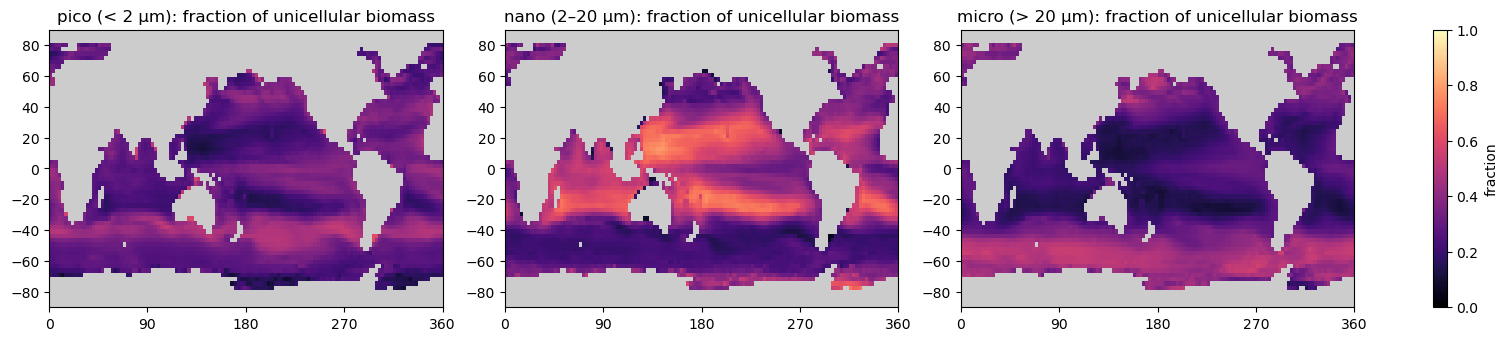

In [7]:
esd = 1e4 * 1.5 * (m * 1e-6) ** (1 / 3)
uni = np.isin(ctype, ["Generalists", "Diatoms"])
bins = {"pico (< 2 µm)": uni & (esd <= 2), "nano (2–20 µm)": uni & (esd > 2) & (esd <= 20), "micro (> 20 µm)": uni & (esd > 20)}
s = sims["A100 (Julia/CUDA)"]
parts = {k: integrated(s, v).mean(axis=0) for k, v in bins.items()}
total = sum(parts.values())
fig, axs = plt.subplots(1, 3, figsize=(15, 3.3), constrained_layout=True)
for ax, (k, v) in zip(axs, parts.items()):
    ax.set_facecolor("0.8")
    pc = ax.pcolormesh(x, y, (v / total).T, vmin=0, vmax=1, cmap="magma", shading="auto")
    ax.set_title(f"{k}: fraction of unicellular biomass"); ax.set_xticks([0, 90, 180, 270, 360])
fig.colorbar(pc, ax=axs, label="fraction")

## 6. Size spectra at four stations

Annual-mean biomass spectrum in the surface layer, normalized as the Sheldon spectrum
B_i / ln(m_upper/m_lower) (biomass per log-mass bin width), per group. Coloured lines: A100;
black crosses: Matlab (they sit on the lines where the runs agree).

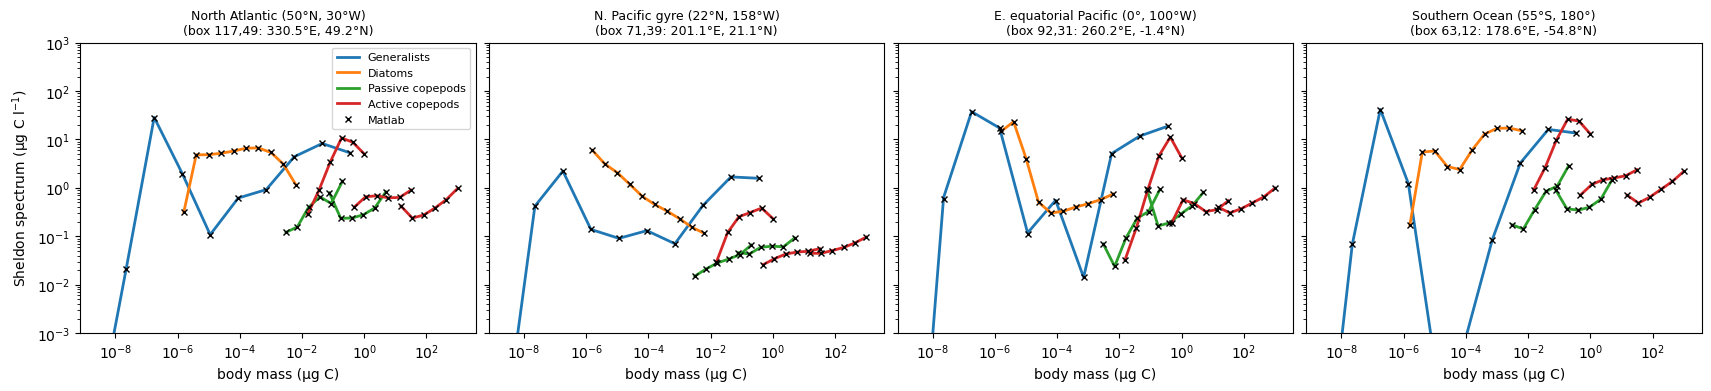

In [8]:
stations = {"North Atlantic (50°N, 30°W)": (330, 50), "N. Pacific gyre (22°N, 158°W)": (202, 22),
            "E. equatorial Pacific (0°, 100°W)": (260, 0), "Southern Ocean (55°S, 180°)": (180, -55)}
width = np.log((mLower + mDelta) / mLower)
colors = dict(zip(groups, plt.cm.tab10.colors))
fig, axs = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True, constrained_layout=True)
for ax, (sname, (lon, lat)) in zip(axs, stations.items()):
    i, j = np.argmin(abs(x - lon)), np.argmin(abs(y - lat))
    for name, s in sims.items():
        spec = np.nanmean(s["B"][:, i, j, 0, :], axis=0) / width
        for grp in groups:
            if grp == "POM":
                continue
            for gi in np.unique(cgroup[ctype == grp]):
                sel = cgroup == gi
                first = gi == cgroup[ctype == grp][0]
                if "A100" in name:
                    ax.loglog(m[sel], spec[sel], "-", color=colors[grp], lw=2, label=grp if first else None)
                else:
                    ax.loglog(m[sel], spec[sel], "x", color="k", ms=4, label="Matlab" if (first and grp == "Generalists") else None)
    ax.set_title(f"{sname}\n(box {i},{j}: {x[i]:.1f}°E, {y[j]:.1f}°N)", fontsize=9)
    ax.set_xlabel("body mass (µg C)"); ax.set_ylim(1e-3, 1e3)
axs[0].set_ylabel("Sheldon spectrum (µg C l$^{-1}$)"); axs[0].legend(fontsize=8)

## 7. Seasonal cycle at the North Atlantic station

Surface biomass of each group through the year: the spring bloom (diatoms first), followed by
copepods. Coloured lines: A100; black crosses: Matlab.

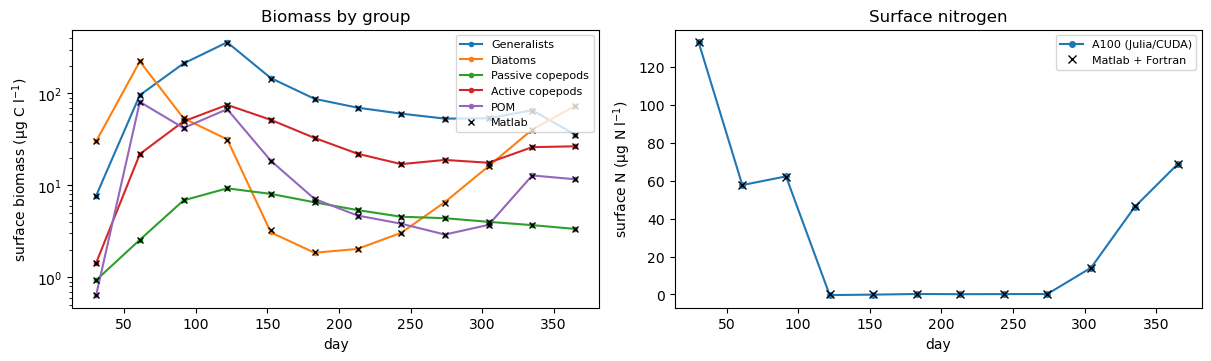

In [9]:
lon, lat = stations["North Atlantic (50°N, 30°W)"]
i, j = np.argmin(abs(x - lon)), np.argmin(abs(y - lat))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
for name, s in sims.items():
    for grp in groups:
        b = np.nansum(s["B"][:, i, j, 0, ctype == grp], axis=1)
        if "A100" in name:
            ax[0].semilogy(t, b, "-o", ms=3, color=colors[grp], label=grp)
        else:
            ax[0].semilogy(t, b, "x", color="k", ms=5, label="Matlab" if grp == groups[0] else None)
    ax[1].plot(t, s["N"][:, i, j, 0], "-o" if "A100" in name else "kx", ms=4 if "A100" in name else 6, label=name)
ax[0].set(xlabel="day", ylabel="surface biomass (µg C l$^{-1}$)", title="Biomass by group"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="day", ylabel="surface N (µg N l$^{-1}$)", title="Surface nitrogen"); ax[1].legend(fontsize=8)

## 8. Zonal-mean section (annual mean total biomass)

Total plankton biomass (all groups except POM), averaged along longitude, versus latitude and depth.

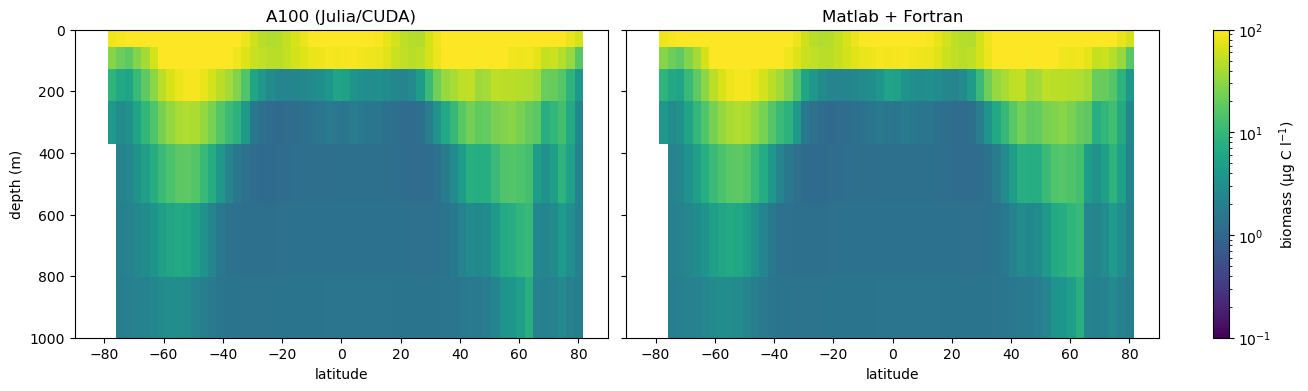

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True, constrained_layout=True)
live = ctype != "POM"
for ax, (name, s) in zip(axs, sims.items()):
    Bt = np.nanmean(np.nansum(s["B"][..., live], axis=4) * np.where(np.isnan(s["N"]), np.nan, 1), axis=0)  # x,y,z
    zm = np.nanmean(Bt, axis=0)                                                                         # y,z
    pc = ax.pcolormesh(y, z, zm.T, norm=LogNorm(1e-1, 1e2), cmap="viridis", shading="auto")
    ax.set_title(name); ax.set_xlabel("latitude"); ax.set_ylim(1000, 0)
axs[0].set_ylabel("depth (m)")
fig.colorbar(pc, ax=axs, label="biomass (µg C l$^{-1}$)")